In [44]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [27]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')

32033 words, 26 unique characters


In [65]:
# create the dataset
# define vocabulary and mappings
xs, ys = [], []
xs_ch, ys_ch = [], [] #for debugging
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] #input character ix
        ix2 = stoi[ch2] #target character ix
        xs.append(ix1) #buildinput character ix
        ys.append(ix2) #build target character ix
        xs_ch.append(ch1) #for debugging
        ys_ch.append(ch2) #for debugging
xs = torch.tensor(xs) #inputs (['.', e, m, m, a]) 1st character as input
ys = torch.tensor(ys) #targets (['e', m, m, a, '.']) 2nd character as target
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [66]:
# example of input and target character indices
xs_ch[0:5], ys_ch[0:5], xs[0:5], ys[0:5]

(['.', 'e', 'm', 'm', 'a'],
 ['e', 'm', 'm', 'a', '.'],
 tensor([ 0,  5, 13, 13,  1]),
 tensor([ 5, 13, 13,  1,  0]))

In [67]:
def train_NN(n_iter=100, lr=50):
    losses, steps = [], []
    # gradient descent
    for k in range(n_iter):
        steps.append(k+1)
        
        # forward pass
        xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoding
        logits = xenc @ W                             # predict log-counts
        counts = logits.exp()                         # counts, equivalent to N
        probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
        loss = -probs[torch.arange(num), ys].log().mean() 
        #print(k, loss.item())
        losses.append(loss.item())

        # backward pass
        W.grad = None # set to zero the gradient
        loss.backward()

        # update
        W.data += -lr * W.grad
    return [steps, losses]

In [68]:
#run the training loop
_train_loss = train_NN(n_iter=100, lr=50) # _train_loss[0] are the steps, _train_loss[1] are the losses

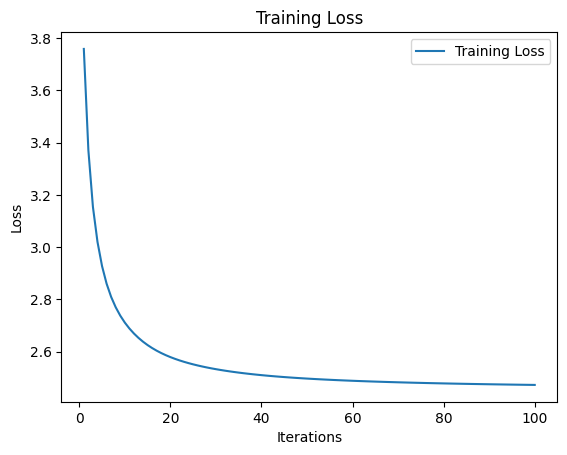

In [69]:
# Retrieve each dictionary's values
train_values = _train_loss[1]
 
# Generate a sequence of integers to represent the iteration numbers
n_iter = _train_loss[0]
 
# Plot and label the training and validation loss values
plt.plot(n_iter, train_values, label='Training Loss')
 
# Add in a title and axes labels
plt.title('Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
 
# Set the tick locations
# plt.xticks(np.arange(0, 21, 2))
 
# Display the plot
plt.legend(loc='best')
plt.show()